기존의 고정된 컴포넌트 GMM 학습 방식에서 계층적 GMM(H-GMM)으로 넘어오면서 변경된 로직과 새롭게 추가된 HierarchicalGMM 클래스에 대해 명확하게 비교하며 설명한다.

## 핵심 로직 변경점: '주어진 K로 학습' vs '최적의 K를 탐색'

가장 큰 차이점은 GMM의 컴포넌트 수(K)를 다루는 방식이다.

**기존 GMM 학습:**
"K=500으로 정해놨으니, 이 500개 클러스터에 데이터를 가장 잘 맞춰봐."

  * 사용자가 N\_CLUSTERS = 500이라는 하이퍼파라미터를 사전에 지정한다.
  * 모델은 이 500개라는 제약 조건 안에서 최선의 파라미터를 찾을 뿐, 500개가 적절한 숫자인지는 판단하지 않는다.

**계층적 GMM (H-GMM) 학습:**
"K=1부터 시작해서, 클러스터를 나누는 게 통계적으로 의미가 있을 때만 나눠. 가장 합리적인 K를 스스로 찾아봐."

  * 사용자는 최대 몇 개까지 탐색할지(max\_components)만 정해준다.
  * 모델이 BIC라는 통계적 기준을 사용해 K=1, K=2, K=3... 순서로 테스트하며 데이터에 가장 적합한 K를 능동적으로 찾아낸다.

이러한 변화로 인해, GMM 모델을 불러오던 부분이 H-GMM을 직접 학습시키는 로직으로 대체되었다.

## HierarchicalGMM 클래스 상세 설명

이 클래스는 제안했던 계층적 분할 알고리즘의 심장부이다.

### **init**(self, ...)

  * **max\_components**: K를 어디까지 탐색할지 정하는 상한선이다.
  * **min\_points\_per\_component**: 통계적 안정을 위해 너무 작은 클러스터가 생성되는 것을 방지한다.
  * 이 외에 최종적으로 찾은 최적의 GMM 파라미터들(n\_components, weights\_, means\_, covariances\_)을 저장할 변수들을 초기화한다.

### \_calculate\_bic(self, ...)

  * BIC 점수를 계산하는 유틸리티 함수이다.
  * GMM의 파라미터 개수(복잡도)와 데이터에 대한 로그 우도(적합도)를 이용해 통계적 모델 성능 점수를 계산한다. 이 점수가 낮을수록 더 좋은 모델이다.

### \_split\_component\_and\_fit(self, ...)

  * 컴포넌트 분할의 핵심 로직을 담고 있다.
  * 분할할 컴포넌트(component\_to\_split)에 할당된 데이터만 추출한다.
  * 이 데이터들에 대해 PCA를 수행하여 데이터가 가장 길게 퍼져있는 방향을 찾는다.
  * 기존 중심점을 이 방향의 양쪽으로 약간씩 이동시켜 두 개의 새로운 초기 중심점을 생성한다.
  * 이 초기값을 바탕으로 2-GMM을 학습시켜, 하나의 컴포넌트를 두 개의 새로운 컴포넌트로 효과적으로 분할한다.

### fit(self, X)

전체 계층적 학습 과정을 총괄하는 메인 메소드이다.

  * **시작 (K=1)**: 모든 데이터를 단일 클러스터로 간주하고 GMM을 학습시켜 best\_model과 best\_bic를 초기화한다.
  * **반복 루프**: 현재 best\_model의 K가 max\_components보다 작은 동안 계속 반복한다.
  * **후보 생성**: 현재 best\_model에 있는 모든 클러스터(1번부터 K번까지)를 각각 \_split\_component\_and\_fit 메소드를 이용해 쪼개보는 \*\*K개의 후보 모델(K+1개 컴포넌트)\*\*을 만든다.
  * **후보 평가 및 미세 조정**: 각 후보 모델을 전체 데이터로 다시 한번 짧게 학습시켜 파라미터를 미세 조정하고, BIC 점수를 계산한다.
  * **최선 선택**: K개의 후보 중 BIC 점수가 가장 낮은(min) 후보를 best\_candidate로 선택한다.
  * **종료 조건 확인**: best\_candidate의 BIC 점수가 현재 best\_bic보다 낮을 경우에만 (즉, 분할이 통계적으로 유의미할 때만) best\_model을 이 후보로 교체하고 루프를 계속한다. 만약 BIC가 개선되지 않으면, \*\*"이득보다 비용이 크다"\*\*고 판단하고 학습을 종료한다.
  * **결과 저장**: 최종적으로 선택된 best\_model의 파라미터들을 클래스 변수(self.means\_ 등)에 저장한다.

## 코드 변경점 요약

| 구분 | 기존 GMM 학습 코드 | 계층적 GMM 코드 |
| :--- | :--- | :--- |
| **GMM 클래스** | PyTorchGMM | PyTorchGMM + HierarchicalGMM (신규) |
| **핵심 로직** | 1. (오프라인) PyTorchGMM으로 미리 학습\<br\>2. joblib.load()로 결과 로드 | 1. (온라인) HierarchicalGMM.fit() 호출\<br\>2. 내부에서 PyTorchGMM을 반복적으로 사용하며 최적 모델 탐색 |
| **컴포넌트 수(K)** | 사용자가 사전 지정 (N\_CLUSTERS = 500) | 알고리즘이 스스로 결정 (N\_CLUSTERS = hgmm.n\_components) |
| **최종 결과** | 500개 컴포넌트를 가진 GMM | BIC 기준으로 가장 합리적인 K개의 컴포넌트를 가진 GMM |

결론적으로, 단순히 모델을 불러와 사용하던 수동적인 방식에서, 데이터의 구조를 스스로 분석하여 가장 적절한 복잡도를 찾아내는 능동적이고 지능적인 방식으로 로직이 근본적으로 변경되었다. 🧐

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm, trange
import joblib
import time
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
import warnings

# 경고 메시지 무시 (수렴 실패 등 GMM 학습 시 발생 가능)
warnings.filterwarnings('ignore', category=UserWarning)

# ================================================================
# 1. 기본 설정 및 경로 정의
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')

# --- 결과 저장 경로 ---
OUTPUT_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# 2. 필요한 클래스 및 함수 정의
# ================================================================
print("Step 2: 모델 및 유틸리티 클래스 정의")

# --- VAE 모델 클래스 (Encoder, Decoder, ResBlock) ---
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2),
            nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8),
            nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1),
            ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1),
            ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh()
        )
    def forward(self, z): return self.decoder(z)

# --- 데이터셋 클래스 ---
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

# --- PyTorchGMM 클래스 (기능 확장) ---
class PyTorchGMM:
    def __init__(self, n_components, max_iter=200, tol=1e-8, reg_covar=1e-6, random_state=42):
        self.n_components, self.max_iter, self.tol = n_components, max_iter, tol
        self.reg_covar, self.random_state = reg_covar, random_state
        self.device = DEVICE
        self.weights_, self.means_, self.covariances_ = None, None, None
        self.converged_ = False
        self.log_likelihood_ = -torch.inf

    def fit(self, X, initial_means=None):
        if self.random_state: torch.manual_seed(self.random_state)
        X = X.to(self.device)
        n_samples, n_features = X.shape
        
        # <<< 수정: 초기 평균값을 받아 파라미터를 초기화하는 기능 추가 >>>
        self._initialize_parameters(X, initial_means)
        
        log_likelihood = -torch.inf
        
        for i in range(self.max_iter):
            prev_log_likelihood = log_likelihood
            log_prob_norm, log_responsibilities = self._e_step(X)
            self._m_step(X, log_responsibilities)
            log_likelihood = torch.mean(log_prob_norm)
            
            if i > 0 and torch.abs(log_likelihood - prev_log_likelihood) < self.tol:
                self.converged_ = True
                break
        
        if not self.converged_:
            print(f"Warning: GMM with {self.n_components} components did not converge in {self.max_iter} iterations.")

        # <<< 추가: 최종 로그 우도(Log-Likelihood) 저장 >>>
        # BIC 계산을 위해 전체 데이터에 대한 총합 로그 우도가 필요
        self.log_likelihood_ = torch.sum(log_prob_norm).item()

    def _initialize_parameters(self, X, initial_means):
        n_samples, n_features = X.shape
        if initial_means is not None and initial_means.shape == (self.n_components, n_features):
            self.means_ = initial_means.to(self.device)
        else:
            indices = torch.randperm(n_samples, device=self.device)[:self.n_components]
            self.means_ = X[indices]
            
        self.weights_ = torch.full((self.n_components,), 1/self.n_components, device=self.device)
        self.covariances_ = torch.eye(n_features, device=self.device).unsqueeze(0).repeat(self.n_components, 1, 1)

    def _e_step(self, X):
        weighted_log_prob = self._estimate_weighted_log_prob(X)
        log_prob_norm = torch.logsumexp(weighted_log_prob, dim=1)
        log_responsibilities = weighted_log_prob - log_prob_norm.unsqueeze(1)
        return log_prob_norm, log_responsibilities

    def _m_step(self, X, log_responsibilities):
        responsibilities = torch.exp(log_responsibilities)
        nk = torch.sum(responsibilities, dim=0) + 1e-10
        self.weights_ = nk / X.shape[0]
        self.means_ = torch.matmul(responsibilities.T, X) / nk.unsqueeze(1)
        for k in range(self.n_components):
            diff = X - self.means_[k]
            cov_k = torch.matmul((responsibilities[:, k].unsqueeze(1) * diff).T, diff) / nk[k]
            cov_k.add_(torch.eye(X.shape[1], device=self.device) * self.reg_covar)
            self.covariances_[k] = cov_k

    def _estimate_weighted_log_prob(self, X):
        log_probs = []
        for k in range(self.n_components):
            try:
                dist = torch.distributions.MultivariateNormal(self.means_[k], self.covariances_[k])
                log_probs.append(dist.log_prob(X))
            except ValueError: # 공분산 행렬 문제 발생 시
                return torch.full((X.shape[0], self.n_components), -torch.inf, device=self.device, dtype=X.dtype)
        log_probs = torch.stack(log_probs, dim=1)
        return log_probs + torch.log(self.weights_)

# --- 계층적 GMM 클래스 ---
class HierarchicalGMM:
    def __init__(self, max_components=30, min_points_per_component=20, random_state=42):
        self.max_components = max_components
        self.min_points = min_points_per_component
        self.random_state = random_state
        self.n_components, self.weights_, self.means_, self.covariances_ = 0, None, None, None

    def _calculate_bic(self, n_samples, gmm):
        n_features = gmm.means_.shape[1]
        k = gmm.n_components
        n_params = (k - 1) + (k * n_features) + (k * n_features * (n_features + 1) / 2)
        return n_params * np.log(n_samples) - 2 * gmm.log_likelihood_

    def _split_component_and_fit(self, X, assignments, component_to_split, old_model):
        data_subset_indices = torch.where(assignments == component_to_split)[0]
        if len(data_subset_indices) < self.min_points * 2: return None
        
        data_subset = X[data_subset_indices]
        pca = PCA(n_components=1, random_state=self.random_state)
        pca.fit(data_subset.cpu().numpy())
        pc_vector = torch.from_numpy(pca.components_[0]).to(X.device).float()

        old_mean = old_model.means_[component_to_split]
        old_cov = old_model.covariances_[component_to_split]
        # 분산이 큰 방향으로 적절히 이동
        shift_magnitude = torch.sqrt(torch.max(torch.diag(old_cov)))
        
        initial_means = torch.stack([old_mean + pc_vector * shift_magnitude * 0.2, 
                                     old_mean - pc_vector * shift_magnitude * 0.2], dim=0)

        split_gmm = PyTorchGMM(n_components=2, random_state=self.random_state)
        split_gmm.fit(data_subset, initial_means=initial_means)
        
        if not split_gmm.converged_: return None # 분할 후 수렴 실패 시 후보에서 제외
        
        return split_gmm

    def fit(self, X):
        print("계층적 GMM 학습을 시작합니다.")
        n_samples, _ = X.shape

        # 1. 시작: K=1 GMM으로 초기화
        best_model = PyTorchGMM(n_components=1, random_state=self.random_state)
        best_model.fit(X)
        best_bic = self._calculate_bic(n_samples, best_model)
        print(f"시작 (K=1): BIC = {best_bic:.2f}")

        while best_model.n_components < self.max_components:
            current_k = best_model.n_components
            
            # 현재 모델 기준으로 데이터 할당
            log_prob_norm, log_resp = best_model._e_step(X)
            assignments = torch.argmax(log_resp, dim=1)
            
            candidate_models = []
            
            # 2. 후보 생성: 모든 컴포넌트를 한번씩 분할 시도
            for i in trange(current_k, desc=f"Splitting K={current_k}"):
                split_gmm = self._split_component_and_fit(X, assignments, i, best_model)
                if split_gmm is None: continue

                # 분할된 컴포넌트(2개)와 나머지 컴포넌트(K-1개)를 합쳐 새 모델 구성
                candidate_gmm = PyTorchGMM(n_components=current_k + 1, random_state=self.random_state)
                
                # 가중치 재계산
                new_weights = list(best_model.weights_.cpu().numpy())
                split_weight = new_weights.pop(i)
                new_weights.extend(split_gmm.weights_.cpu().numpy() * split_weight)
                candidate_gmm.weights_ = torch.tensor(new_weights, device=DEVICE)

                # 평균, 공분산 결합
                new_means = list(torch.unbind(best_model.means_, dim=0))
                new_means.pop(i)
                new_means.extend(list(torch.unbind(split_gmm.means_, dim=0)))
                candidate_gmm.means_ = torch.stack(new_means, dim=0)

                new_covs = list(torch.unbind(best_model.covariances_, dim=0))
                new_covs.pop(i)
                new_covs.extend(list(torch.unbind(split_gmm.covariances_, dim=0)))
                candidate_gmm.covariances_ = torch.stack(new_covs, dim=0)
                
                # 전체 데이터로 EM step을 몇 번 더 돌려 파라미터 미세조정 (Refinement)
                candidate_gmm.fit(X, initial_means=candidate_gmm.means_) # 초기값 주고 재학습
                
                bic = self._calculate_bic(n_samples, candidate_gmm)
                candidate_models.append({'model': candidate_gmm, 'bic': bic})

            # 3. 최선 선택 및 종료 조건 확인
            if not candidate_models:
                print("더 이상 분할할 수 있는 유효한 후보가 없습니다.")
                break
                
            best_candidate = min(candidate_models, key=lambda x: x['bic'])
            
            if best_candidate['bic'] < best_bic:
                best_model = best_candidate['model']
                best_bic = best_candidate['bic']
                print(f"분할 성공 (K={best_model.n_components}): Best BIC = {best_bic:.2f}")
            else:
                print("BIC가 더 이상 개선되지 않아 학습을 종료합니다.")
                break
        
        print(f"\n학습 종료. 최종 최적 컴포넌트 수: {best_model.n_components}")
        self.n_components = best_model.n_components
        self.weights_ = best_model.weights_.cpu().numpy()
        self.means_ = best_model.means_.cpu()
        self.covariances_ = best_model.covariances_.cpu()
        return self

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    # --- 1. 모델 및 데이터 로드 ---
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()
    print("Encoder 모델 로드 완료.")

    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    train_dataset_full = CustomImageDataset(DATA_DIR, transform)
    # 실험을 위해 데이터 수를 줄여서 사용
    train_dataset = Subset(train_dataset_full, list(range(10000)))
    loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=4)

    # --- 2. 잠재 벡터 추출 ---
    print("\nStep 3.2: 잠재 벡터(mu) 추출")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    
    latent_vectors_tensor = torch.cat(all_mu_vectors_flat, dim=0)
    print(f"총 {latent_vectors_tensor.shape[0]}개의 잠재 벡터 추출 완료 (차원: {latent_vectors_tensor.shape[1]}).")

    # --- 3. 계층적 GMM 학습 ---
    print("\nStep 3.3: 계층적 GMM 학습 시작")
    hgmm = HierarchicalGMM(max_components=30) # 최대 30개까지 탐색
    start_time = time.time()
    hgmm.fit(latent_vectors_tensor)
    elapsed_time = time.time() - start_time
    print(f"GMM fitting 완료. 소요 시간: {elapsed_time:.2f}초")

    # --- 4. 결과 저장 ---
    print("\nStep 3.4: 최적 GMM 파라미터 저장")
    gmm_state_dict = {
        'weights': hgmm.weights_,
        'means': hgmm.means_.numpy(),
        'covariances': hgmm.covariances_.numpy(),
        'n_components': hgmm.n_components
    }
    save_path = os.path.join(OUTPUT_DIR, f'hgmm_best_{hgmm.n_components}_components.pkl')
    joblib.dump(gmm_state_dict, save_path)
    print(f"최적 GMM 파라미터 저장 완료: {save_path}")

if __name__ == '__main__':
    main()

Step 1: 기본 설정 로드
Step 2: 모델 및 유틸리티 클래스 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2428374/3890654582.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))


Encoder 모델 로드 완료.

Step 3.2: 잠재 벡터(mu) 추출


잠재 벡터 추출 중:   0%|          | 0/157 [00:00<?, ?it/s]

총 10000개의 잠재 벡터 추출 완료 (차원: 256).

Step 3.3: 계층적 GMM 학습 시작
계층적 GMM 학습을 시작합니다.
시작 (K=1): BIC = 6240089.70


Splitting K=1:   0%|          | 0/1 [00:00<?, ?it/s]

BIC가 더 이상 개선되지 않아 학습을 종료합니다.

학습 종료. 최종 최적 컴포넌트 수: 1
GMM fitting 완료. 소요 시간: 2.03초

Step 3.4: 최적 GMM 파라미터 저장
최적 GMM 파라미터 저장 완료: /home/nas/data/YMG/superdeep_ae/H_gmm_results/hgmm_best_1_components.pkl


/tmp/ipykernel_2428374/2568201547.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))


모델 로드 완료. Cluster 1개에서 이미지 생성을 시작합니다.
생성된 이미지 그리드 저장 완료: /home/nas/data/YMG/superdeep_ae/H_gmm_results/generated_grid_64_samples.png


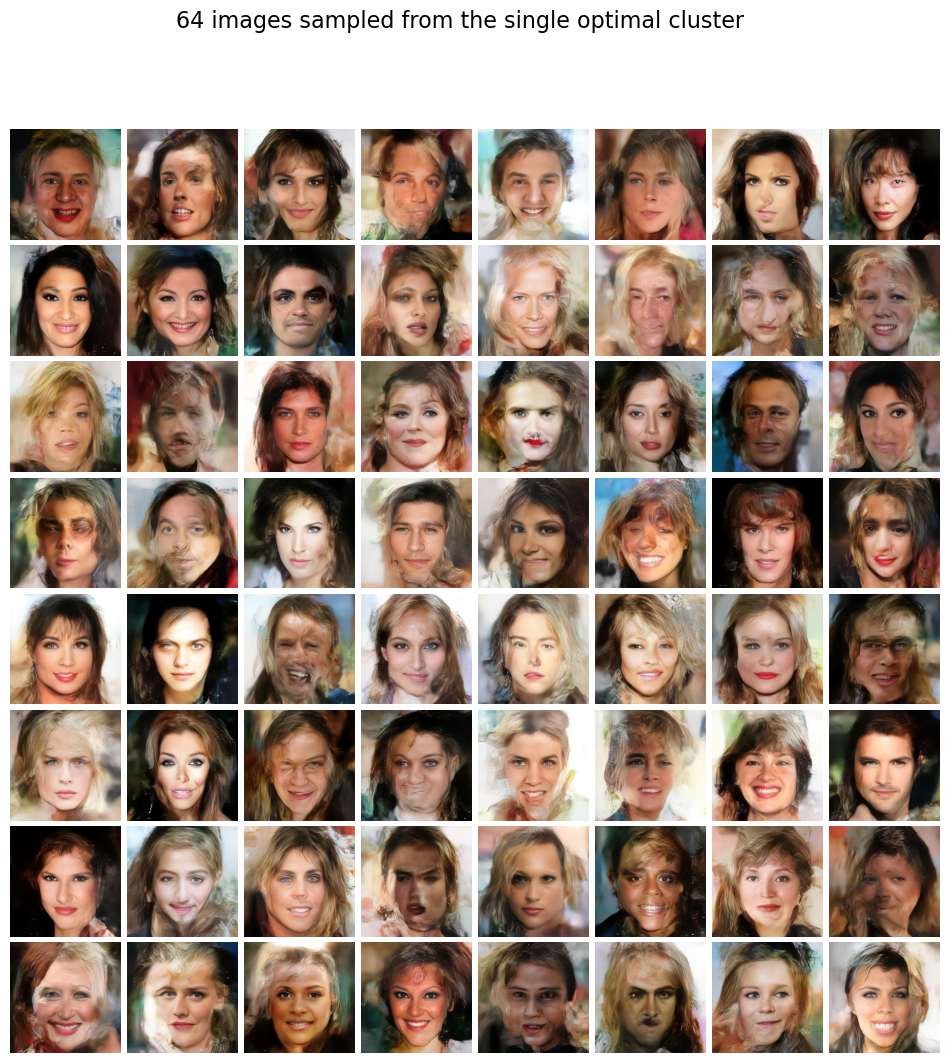

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision.utils import save_image
import joblib
import matplotlib.pyplot as plt

# --- 이전에 정의했던 VAE 모델 클래스들은 동일하게 필요합니다 ---
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1),
            ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1),
            ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh()
        )
    def forward(self, z): return self.decoder(z)

# -----------------------------------------------------------------

def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5

def generate_from_single_cluster():
    # --- 1. 설정 및 모델 로드 ---
    DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
    
    # VAE Decoder 로드
    AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
    DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')
    decoder = DecoderSuperDeep().to(DEVICE)
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    decoder.eval()
    
    # H-GMM 모델 로드
    GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results/'
    GMM_PATH = os.path.join(GMM_DIR, 'hgmm_best_1_components.pkl') # 생성된 파일 경로
    gmm_params = joblib.load(GMM_PATH)
    
    mean = torch.from_numpy(gmm_params['means'][0]).to(DEVICE)      # 첫 번째(유일한) 컴포넌트의 평균
    covariance = torch.from_numpy(gmm_params['covariances'][0]).to(DEVICE) # 첫 번째 컴포넌트의 공분산
    
    OUTPUT_DIR = GMM_DIR # 결과는 같은 폴더에 저장
    print(f"모델 로드 완료. Cluster 1개에서 이미지 생성을 시작합니다.")

    # --- 2. 단일 클러스터에서 샘플링 ---
    num_samples = 64 # 8x8 그리드 생성
    
    # 유일한 가우시안 분포 정의
    dist = torch.distributions.MultivariateNormal(mean, covariance)
    
    # 해당 분포에서 N개의 잠재 벡터 샘플링
    # view()를 통해 디코더 입력 모양(B, C, H, W)으로 맞춰줌
    latents = dist.sample((num_samples,)).view(num_samples, 1, 16, 16)

    # --- 3. 디코더로 이미지 생성 ---
    with torch.no_grad():
        generated_images = decoder(latents).cpu()
    
    # --- 4. 시각화 및 저장 ---
    images_to_show = denormalize(generated_images)
    grid_size = int(np.sqrt(num_samples))
    
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    fig.suptitle(f'{num_samples} images sampled from the single optimal cluster', fontsize=16)
    
    img_iter = iter(images_to_show)
    for ax in axes.flat:
        ax.imshow(next(img_iter).permute(1, 2, 0))
        ax.axis('off')
    
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    
    save_path = os.path.join(OUTPUT_DIR, f'generated_grid_{num_samples}_samples.png')
    plt.savefig(save_path, bbox_inches='tight')
    print(f"생성된 이미지 그리드 저장 완료: {save_path}")
    plt.show()

if __name__ == '__main__':
    generate_from_single_cluster()

Step 1: 기본 설정 로드
Step 2: 모델 클래스 및 함수 정의

Step 3.1: 모델 및 데이터 로드


/tmp/ipykernel_2428374/2383032482.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
/tmp/ipykernel

Autoencoder 모델 로드 완료.
Hierarchical GMM 모델 로드 완료. 최적 클러스터 수: 1

Step 3.2: 잠재 벡터 추출 및 클러스터 할당


평균 벡터(mu) 추출 중:   0%|          | 0/157 [00:00<?, ?it/s]

클러스터 할당 완료 (모든 데이터가 0번 클러스터에 할당됨).

--- 분석 1: 클러스터 분석 결과 ---
총 1개의 클러스터 중, 데이터가 할당된 클러스터 수: 1개

--- 분석 2: 클러스터별 샘플링 및 시각화 ---


클러스터별 비교 이미지 생성 중:   0%|          | 0/1 [00:00<?, ?it/s]

클러스터별 비교 이미지 저장 완료.

--- 분석 3: 그리드 샘플링 및 시각화 ---

--- 64개(8x8) 이미지 그리드 생성 ---
그리드 이미지 저장 완료: /home/nas/data/YMG/superdeep_ae/H_gmm_results/grid_samples/grid_64_samples.png


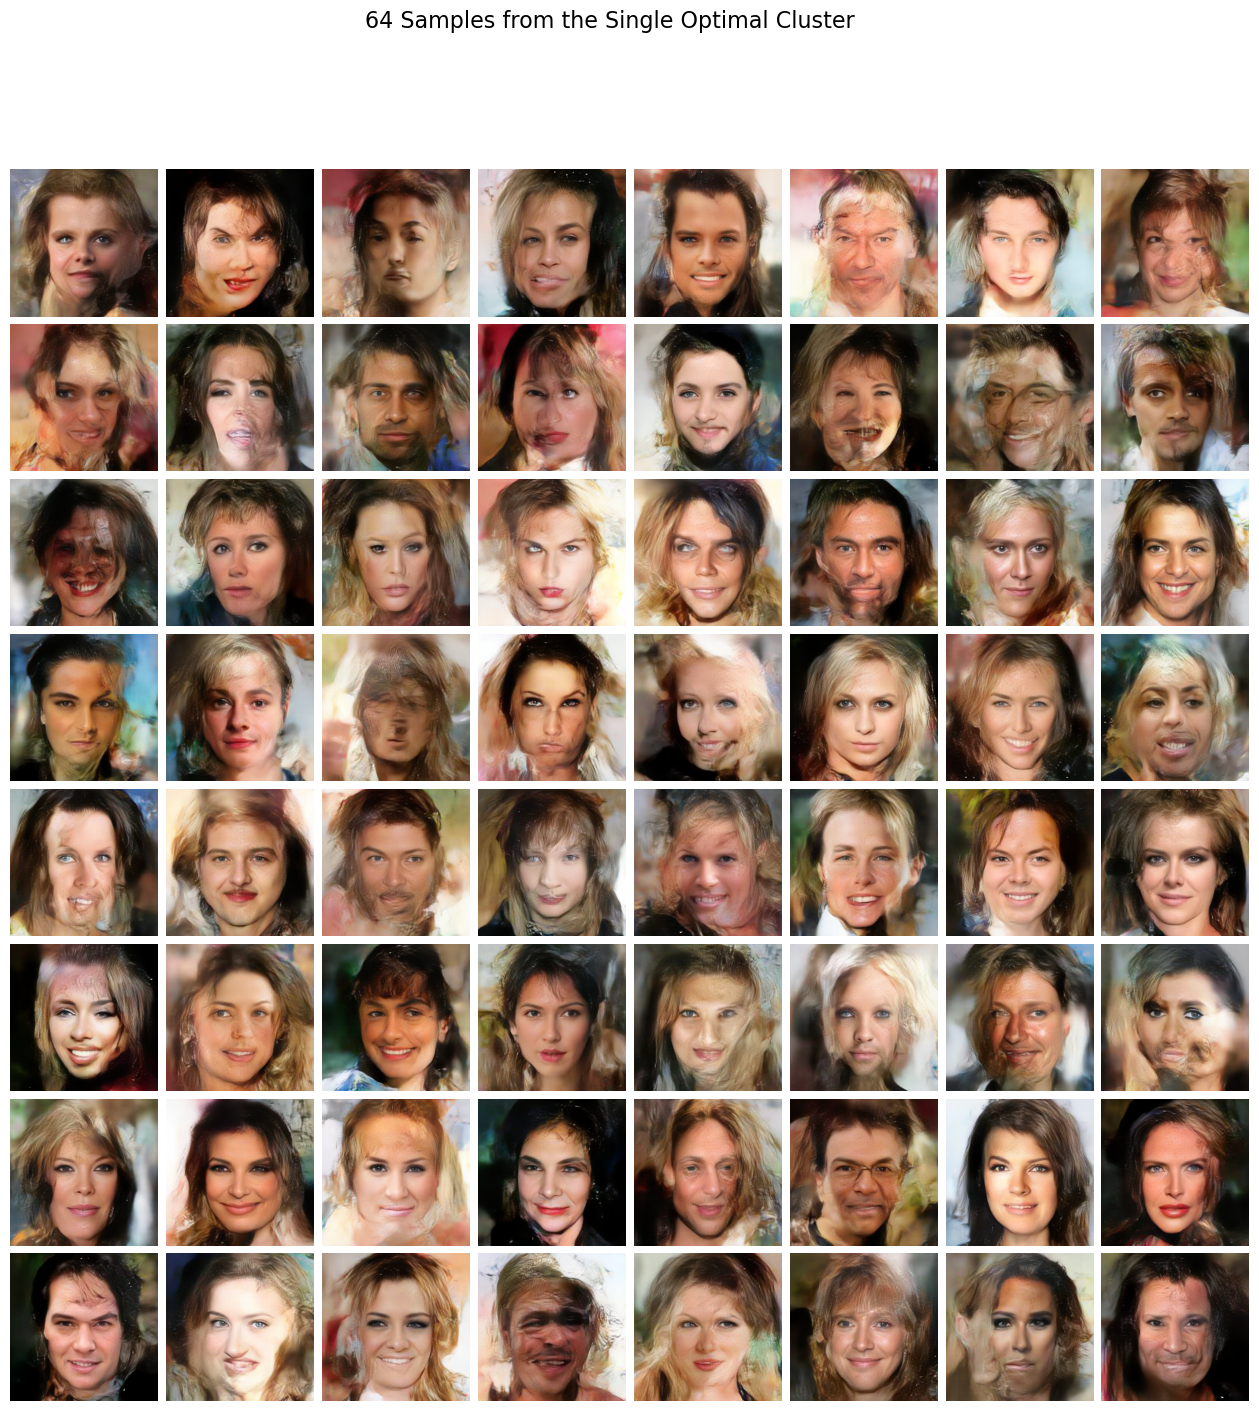

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.utils import save_image
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
import random

# ================================================================
# 1. 기본 설정 및 경로 정의 (수정됨)
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')

# --- H-GMM 모델 경로 ---
GMM_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results/'
GMM_PATH = os.path.join(GMM_DIR, 'hgmm_best_1_components.pkl') # 학습된 H-GMM 결과 파일

# --- 결과 저장 경로 ---
OUTPUT_DIR = GMM_DIR # 결과는 H-GMM 폴더에 저장
os.makedirs(os.path.join(OUTPUT_DIR, 'cluster_comparisons'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'grid_samples'), exist_ok=True)


# ================================================================
# 2. 필요한 클래스 및 함수 정의 (이전과 동일)
# ================================================================
print("Step 2: 모델 클래스 및 함수 정의")
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2),
            nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8),
            nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1),
            ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1),
            ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh()
        )
    def forward(self, z): return self.decoder(z)

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5

# ================================================================
# 3. 메인 실행 파이프라인 (H-GMM 결과에 맞게 수정됨)
# ================================================================
def main():
    # --- 모델 및 데이터 로드 ---
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    decoder = DecoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    encoder.eval(); decoder.eval()
    print("Autoencoder 모델 로드 완료.")

    gmm_params = joblib.load(GMM_PATH)
    N_CLUSTERS = gmm_params['n_components'] # H-GMM 결과로부터 클러스터 수 로드
    gmm_means = torch.from_numpy(gmm_params['means']).float().to(DEVICE)
    gmm_covs = torch.from_numpy(gmm_params['covariances']).float().to(DEVICE)
    print(f"Hierarchical GMM 모델 로드 완료. 최적 클러스터 수: {N_CLUSTERS}")

    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    train_dataset_full = CustomImageDataset(DATA_DIR, transform)
    # 분석에는 학습 시 사용했던 동일한 데이터 수 사용
    train_dataset = Subset(train_dataset_full, list(range(10000)))
    loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=4)

    # --- 잠재 벡터 추출 및 클러스터 할당 ---
    print("\nStep 3.2: 잠재 벡터 추출 및 클러스터 할당")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="평균 벡터(mu) 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1).cpu())
    
    all_mu_vectors_flat = torch.cat(all_mu_vectors_flat, dim=0).to(DEVICE)
    
    # K=1 이므로 모든 데이터는 0번 클러스터에 할당됨
    assignments = torch.zeros(len(all_mu_vectors_flat), dtype=torch.long)
    print("클러스터 할당 완료 (모든 데이터가 0번 클러스터에 할당됨).")

    # --- 1. 클러스터 분석 ---
    print("\n--- 분석 1: 클러스터 분석 결과 ---")
    cluster_counts = torch.bincount(assignments, minlength=N_CLUSTERS)
    active_clusters_indices = torch.where(cluster_counts > 0)[0]
    print(f"총 {N_CLUSTERS}개의 클러스터 중, 데이터가 할당된 클러스터 수: {len(active_clusters_indices)}개")

    # --- 2. 클러스터별 샘플링 및 시각화 ---
    print("\n--- 분석 2: 클러스터별 샘플링 및 시각화 ---")
    # K=1 이므로 0번 클러스터만 선택
    selected_clusters = active_clusters_indices.tolist()

    for cluster_idx in tqdm(selected_clusters, desc="클러스터별 비교 이미지 생성 중"):
        original_img_indices = torch.where(assignments == cluster_idx)[0]
        num_assigned = len(original_img_indices)

        mean = gmm_means[cluster_idx]
        cov = gmm_covs[cluster_idx]
        dist = torch.distributions.MultivariateNormal(mean, cov)
        sampled_latents = dist.sample((10,)).view(10, 1, 16, 16)

        with torch.no_grad():
            generated_imgs = decoder(sampled_latents.to(DEVICE)).cpu()

        fig, axes = plt.subplots(2, 10, figsize=(20, 4.5))
        fig.suptitle(f'Cluster #{cluster_idx} (Assigned: {num_assigned})', fontsize=16)
        
        # 상단: 원본 이미지 (랜덤으로 10개)
        axes[0, 0].set_title('Original Images in this Cluster', loc='left')
        random_indices = torch.randperm(len(original_img_indices))[:10]
        for i in range(10):
            original_img, _ = train_dataset[original_img_indices[random_indices[i]].item()]
            axes[0, i].imshow(denormalize(original_img).permute(1, 2, 0))
            axes[0, i].axis('off')
        
        # 하단: 생성된 이미지
        axes[1, 0].set_title('Generated Images from this Cluster', loc='left')
        for i in range(10):
            axes[1, i].imshow(denormalize(generated_imgs[i]).permute(1, 2, 0))
            axes[1, i].axis('off')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        save_path = os.path.join(OUTPUT_DIR, f'cluster_comparisons/cluster_{cluster_idx}_comparison.png')
        plt.savefig(save_path)
        plt.close(fig)

    print("클러스터별 비교 이미지 저장 완료.")

    # --- 3. 그리드 샘플링 및 시각화 ---
    print("\n--- 분석 3: 그리드 샘플링 및 시각화 ---")
    sample_counts = [64] # 64개만 생성
    for count in sample_counts:
        grid_size = int(np.sqrt(count))
        print(f"\n--- {count}개({grid_size}x{grid_size}) 이미지 그리드 생성 ---")

        # <<< 수정: 단일 클러스터에서 모두 샘플링 >>>
        mean = gmm_means[0]
        cov = gmm_covs[0]
        dist = torch.distributions.MultivariateNormal(mean, cov)
        latents = dist.sample((count,)).view(count, 1, 16, 16)
        
        with torch.no_grad():
            images = decoder(latents.to(DEVICE)).cpu()
        images = denormalize(images)
        
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2, grid_size * 2))
        fig.suptitle(f"{count} Samples from the Single Optimal Cluster", fontsize=16)
        
        img_iter = iter(images)
        for ax in axes.flat:
            ax.imshow(next(img_iter).permute(1, 2, 0)); ax.axis('off')

        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        
        save_path = os.path.join(OUTPUT_DIR, f'grid_samples/grid_{count}_samples.png')
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
        print(f"그리드 이미지 저장 완료: {save_path}")
        plt.show()

if __name__ == '__main__':
    main()

네, 그 지점은 정말 날카롭고 합리적인 의문입니다. 직관적으로 10,000개의 다양한 얼굴 이미지가 단 하나의 클러스터로 묶인다는 것은 이상하게 들리는 것이 당연합니다.

하지만 이것이 반드시 **계산 오류를 의미하지는 않습니다.** 오히려 GMM과 BIC라는 통계적 잣대가 현재 데이터의 잠재 공간을 어떻게 '해석'했는지를 보여주는 중요한 결과일 수 있습니다.

오류가 아니라고 생각하는 이유를 단계별로 설명해 드리겠습니다.

---

### ## 1. '오류'가 아니라 'BIC의 보수적인 판단'입니다

계층적 GMM의 핵심은 **BIC(Bayesian Information Criterion)** 점수를 낮추는 것입니다. BIC의 공식을 다시 한번 살펴보겠습니다.

$$BIC = k \cdot \ln(n) - 2 \cdot \ln(\hat{L})$$

* $2 \cdot \ln(\hat{L})$: **데이터 적합도 (보상)**. 모델이 데이터를 잘 설명할수록 이 값이 커져서 BIC는 낮아집니다. 클러스터를 1개에서 2개로 쪼개면 이 값은 **언제나** 조금이라도 커집니다.
* $k \cdot \ln(n)$: **모델 복잡도 (페널티)**. 파라미터($k$)가 많아질수록 이 값이 커져서 BIC도 커집니다.

알고리즘이 K=1에서 멈췄다는 것은, 클러스터를 2개로 쪼갰을 때 발생하는 **'보상(적합도 증가)'**보다 **'페널티(복잡도 증가)'**가 훨씬 더 컸다는 의미입니다.

> 즉, "클러스터를 2개로 쪼개서 얻는 약간의 설명력 향상이라는 **이득**보다, 새로 추가되는 수많은 파라미터(평균 벡터, 공분산 행렬)를 감당해야 하는 **비용**이 훨씬 크다" 라고 모델이 판단한 것입니다.

---

### ## 2. 왜 이런 판단을 내렸을까요? (시각적 비유)

10,000개의 잠재 벡터를 2차원 공간에 뿌렸다고 상상해 보겠습니다.

#### **상황 A: BIC가 K>1을 선택하는 경우**

데이터가 위 그림처럼 명확하게 두 개 이상의 덩어리로 나뉘어 있다면, 클러스터를 2개로 나누었을 때 **적합도($\hat{L}$)가 폭발적으로 증가**합니다. 이 보상이 페널티를 상쇄하고도 남기 때문에 BIC는 K=2를 기꺼이 선택합니다.

#### **상황 B: BIC가 K=1을 선택하는 경우**

하지만 데이터가 위 그림처럼 **크고 넓게 퍼진 하나의 덩어리(blob)** 형태를 띠고 있다면 어떻게 될까요? 10,000개의 점들은 모두 다르지만, 뚜렷한 하위 그룹 없이 하나의 거대한 구름처럼 보입니다.

이 경우, 억지로 클러스터를 2개로 나누면 두 개의 가우시안 분포가 서로 심하게 겹치게 됩니다. 적합도는 아주 약간만 개선되지만, 파라미터 수는 거의 두 배로 늘어납니다. BIC는 이 상황을 보고 "이건 그냥 하나의 거대한 가우시안 분포로 설명하는 것이 가장 간결하고 합리적이다"라고 결론 내리게 됩니다.

---

### ## 3. 잠재 공간(Latent Space)의 특성 문제

가장 중요한 점은, GMM이 분석하는 것은 **'이미지'가 아니라 VAE가 만든 '잠재 벡터'**라는 것입니다.

이번 `K=1` 결과는 H-GMM 알고리즘이 잘못되었다기보다는, VAE 인코더가 10,000개의 이미지를 **'상황 B'와 같은 잠재 공간으로 압축했다는 강력한 신호**입니다. 즉, 잠재 공간 내에서 데이터들이 유의미한 여러 그룹으로 나뉘지 않고, 하나의 거대한 덩어리로 뭉쳐있을 가능성이 매우 높습니다.

이런 현상은 VAE 학습 시 다음과 같은 이유로 발생할 수 있습니다.
* **후방 붕괴 (Posterior Collapse)**: VAE가 입력 데이터를 무시하고 모든 이미지를 거의 비슷한 잠재 벡터로 매핑하는, 잘 알려진 학습 실패 모드 중 하나입니다.
* **부족한 표현력**: VAE 모델이나 학습 설정이 데이터의 복잡한 특징들을 서로 분리된 잠재 공간의 여러 지점으로 충분히 펼쳐주지 못했을 수 있습니다.

---

### ## 4. 결론: 코드의 오류인가, 데이터의 특성인가?

따라서 `K=1`이라는 결과는 H-GMM 코드의 **계산 오류일 가능성보다는**, 주어진 잠재 벡터 데이터의 분포를 **통계적으로 정확하게 분석한 결과일 가능성이 훨씬 높습니다.** GMM은 그저 "제가 보기엔 이 데이터는 하위 그룹이 없는 하나의 큰 덩어리입니다"라고 정직하게 보고한 것입니다. 🧐

디버깅의 초점은 `HierarchicalGMM` 코드의 계산 오류를 찾는 것보다, **"왜 VAE가 이런 '뭉쳐진' 잠재 공간을 만들었는가?"**로 옮겨가는 것이 맞습니다.

이 가설을 확인하기 위해 이전에 제안 드렸던 **t-SNE 시각화**를 통해 잠재 벡터의 분포를 직접 그려보는 것이 가장 확실하고 빠른 방법입니다.

VAE를 학습시킬떄 저차원 잠재벡터들을 **단일 표준정규분포** 경계 안으로 들어오도록 KL발산 손실을 통해 학습했는데 이 거대한 단일 표준정규분포를 또 여러개의 표준정규분포로 나눠야 함.  
근데 앞서 진행한 VAE학습에서 KL발산이 강력하게 작용해 저차원 잠재벡터들이 의미있는 하위 구조가 없는 단 하나의 거대한 덩어리가 되었기에 GMM이 이 저차원 잠재공간을 보고 구조적으로 클러스터가 하나라고 판별.(K=1)

In [6]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from tqdm.auto import tqdm, trange
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ================================================================
# 1. 기본 설정 및 경로 정의
# ================================================================
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# --- 모델 경로 ---
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')

# --- 결과 저장 경로 ---
OUTPUT_DIR = '/home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results_diagnostics/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# 2. 필요한 클래스 및 함수 정의
# ================================================================
print("Step 2: 모델 및 유틸리티 클래스/함수 정의")

# --- VAE 인코더 모델 클래스 ---
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2),
            nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4),
            nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8),
            nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16),
            nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

# --- 데이터셋 클래스 ---
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

# --- PyTorchGMM 클래스 ---
class PyTorchGMM:
    def __init__(self, n_components, max_iter=200, tol=1e-8, reg_covar=1e-6, random_state=42):
        self.n_components, self.max_iter, self.tol = n_components, max_iter, tol
        self.reg_covar, self.random_state = reg_covar, random_state
        self.device = DEVICE
        self.weights_, self.means_, self.covariances_ = None, None, None
        self.converged_ = False
        self.log_likelihood_ = -np.inf

    def fit(self, X, initial_means=None):
        if self.random_state: torch.manual_seed(self.random_state)
        X = X.to(self.device)
        n_samples, n_features = X.shape
        self._initialize_parameters(X, initial_means)
        
        log_likelihood = -torch.inf
        for i in range(self.max_iter):
            prev_log_likelihood = log_likelihood
            log_prob_norm, log_responsibilities = self._e_step(X)
            if torch.isinf(log_prob_norm).any() or torch.isnan(log_prob_norm).any():
                self.converged_ = False
                break
            self._m_step(X, log_responsibilities)
            log_likelihood = torch.mean(log_prob_norm)
            if i > 0 and torch.abs(log_likelihood - prev_log_likelihood) < self.tol:
                self.converged_ = True
                break
        
        self.log_likelihood_ = torch.sum(log_prob_norm).item() if not (torch.isinf(log_prob_norm).any() or torch.isnan(log_prob_norm).any()) else -np.inf

    def _initialize_parameters(self, X, initial_means):
        n_samples, n_features = X.shape
        if initial_means is not None and initial_means.shape == (self.n_components, n_features):
            self.means_ = initial_means.to(self.device)
        else:
            indices = torch.randperm(n_samples, device=self.device)[:self.n_components]
            self.means_ = X[indices]
            
        self.weights_ = torch.full((self.n_components,), 1/self.n_components, device=self.device, dtype=torch.float32)
        self.covariances_ = torch.eye(n_features, device=self.device, dtype=torch.float32).unsqueeze(0).repeat(self.n_components, 1, 1)

    def _e_step(self, X):
        weighted_log_prob = self._estimate_weighted_log_prob(X)
        log_prob_norm = torch.logsumexp(weighted_log_prob, dim=1)
        log_responsibilities = weighted_log_prob - log_prob_norm.unsqueeze(1)
        return log_prob_norm, log_responsibilities

    def _m_step(self, X, log_responsibilities):
        responsibilities = torch.exp(log_responsibilities)
        nk = torch.sum(responsibilities, dim=0) + 1e-10
        self.weights_ = nk / X.shape[0]
        self.means_ = torch.matmul(responsibilities.T, X) / nk.unsqueeze(1)
        for k in range(self.n_components):
            diff = X - self.means_[k]
            cov_k = torch.matmul((responsibilities[:, k].unsqueeze(1) * diff).T, diff) / nk[k]
            cov_k.add_(torch.eye(X.shape[1], device=self.device) * self.reg_covar)
            self.covariances_[k] = cov_k

    def _estimate_weighted_log_prob(self, X):
        log_probs = []
        for k in range(self.n_components):
            try:
                # 공분산 행렬의 안정성 확보
                L = torch.linalg.cholesky(self.covariances_[k])
                dist = torch.distributions.MultivariateNormal(self.means_[k], scale_tril=L)
                log_probs.append(dist.log_prob(X))
            except torch.linalg.LinAlgError:
                return torch.full((X.shape[0], self.n_components), -torch.inf, device=self.device, dtype=X.dtype)
        log_probs = torch.stack(log_probs, dim=1)
        return log_probs + torch.log(self.weights_)

# --- 계층적 GMM 클래스 ---
class HierarchicalGMM:
    def __init__(self, max_components=30, min_points_per_component=30, random_state=42):
        self.max_components = max_components
        self.min_points = min_points_per_component
        self.random_state = random_state
        self.n_components, self.weights_, self.means_, self.covariances_ = 0, None, None, None
        self.bics_ = []

    def _calculate_bic(self, n_samples, gmm):
        if not np.isfinite(gmm.log_likelihood_): return np.inf
        n_features = gmm.means_.shape[1]
        k = gmm.n_components
        n_params = (k - 1) + (k * n_features) + (k * n_features * (n_features + 1) / 2)
        return n_params * np.log(n_samples) - 2 * gmm.log_likelihood_

    def _split_component_and_get_initial_means(self, X, assignments, component_to_split, old_model):
        data_subset_indices = torch.where(assignments == component_to_split)[0]
        if len(data_subset_indices) < self.min_points: return None
        
        data_subset = X[data_subset_indices]
        try:
            pca = PCA(n_components=1, random_state=self.random_state)
            pca.fit(data_subset.cpu().numpy())
            pc_vector = torch.from_numpy(pca.components_[0]).to(X.device).float()
        except Exception:
            return None # PCA 실패 시 분할 불가

        old_mean = old_model.means_[component_to_split]
        old_cov = old_model.covariances_[component_to_split]
        shift_magnitude = torch.sqrt(torch.diag(old_cov).max()) * 0.5
        
        mean1 = old_mean + pc_vector * shift_magnitude
        mean2 = old_mean - pc_vector * shift_magnitude
        return mean1, mean2

    def fit(self, X):
        print("계층적 GMM 학습을 시작합니다.")
        n_samples, _ = X.shape

        best_model = PyTorchGMM(n_components=1, random_state=self.random_state)
        best_model.fit(X)
        best_bic = self._calculate_bic(n_samples, best_model)
        self.bics_.append(best_bic)
        print(f"시작 (K=1): BIC = {best_bic:.2f}")

        while best_model.n_components < self.max_components:
            current_k = best_model.n_components
            
            _, log_resp = best_model._e_step(X)
            assignments = torch.argmax(log_resp, dim=1)
            
            best_candidate_bic = np.inf
            best_candidate_model = None
            
            pbar = trange(current_k, desc=f"Splitting K={current_k}")
            for i in pbar:
                initial_means_tuple = self._split_component_and_get_initial_means(X, assignments, i, best_model)
                if initial_means_tuple is None: continue
                
                new_mean1, new_mean2 = initial_means_tuple
                
                candidate_initial_means = list(torch.unbind(best_model.means_, dim=0))
                candidate_initial_means.pop(i)
                candidate_initial_means.extend([new_mean1, new_mean2])
                candidate_initial_means = torch.stack(candidate_initial_means, dim=0)

                candidate_gmm = PyTorchGMM(n_components=current_k + 1, random_state=self.random_state)
                candidate_gmm.fit(X, initial_means=candidate_initial_means)
                
                if not candidate_gmm.converged_: continue
                
                bic = self._calculate_bic(n_samples, candidate_gmm)
                if bic < best_candidate_bic:
                    best_candidate_bic = bic
                    best_candidate_model = candidate_gmm
            
            if best_candidate_bic < best_bic:
                best_model = best_candidate_model
                best_bic = best_candidate_bic
                self.bics_.append(best_bic)
                print(f"분할 성공 (K={best_model.n_components}): Best BIC = {best_bic:.2f}")
            else:
                print("BIC가 더 이상 개선되지 않아 학습을 종료합니다.")
                break
        
        print(f"\n학습 종료. 최종 최적 컴포넌트 수: {best_model.n_components}")
        self.n_components = best_model.n_components
        self.weights_ = best_model.weights_.cpu().numpy()
        self.means_ = best_model.means_.cpu().numpy()
        self.covariances_ = best_model.covariances_.cpu().numpy()
        return self

# --- 진단용 시각화 함수 ---
def visualize_latent_space(latent_vectors, save_path):
    print("\n잠재 공간을 t-SNE로 시각화합니다...")
    latents_np = latent_vectors.cpu().numpy()
    n_samples_for_viz = min(5000, len(latents_np))
    indices = np.random.choice(len(latents_np), n_samples_for_viz, replace=False)
    
    tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300, random_state=42)
    tsne_results = tsne.fit_transform(latents_np[indices])
    
    plt.figure(figsize=(12, 12))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.5)
    plt.title("Latent Space Visualization with t-SNE")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.grid(True)
    plt.savefig(save_path)
    plt.close()
    print(f"t-SNE 시각화 결과 저장 완료: {save_path}")

# ================================================================
# 3. 메인 실행 파이프라인
# ================================================================
def main():
    # --- 1. 모델 및 데이터 로드 ---
    print("\nStep 3.1: 모델 및 데이터 로드")
    encoder = EncoderSuperDeep().to(DEVICE)
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    encoder.eval()
    print("Encoder 모델 로드 완료.")

    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    # 전체 데이터셋 사용 (30,000개)
    train_dataset = CustomImageDataset(DATA_DIR, transform) 
    loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=4)

    # --- 2. 잠재 벡터 추출 ---
    print("\nStep 3.2: 잠재 벡터(mu) 추출")
    all_mu_vectors_flat = []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="잠재 벡터 추출 중"):
            imgs = imgs.to(DEVICE)
            mu, _ = encoder(imgs)
            all_mu_vectors_flat.append(mu.view(mu.size(0), -1))
    
    latent_vectors_tensor = torch.cat(all_mu_vectors_flat, dim=0).float()
    print(f"총 {latent_vectors_tensor.shape[0]}개의 잠재 벡터 추출 완료 (차원: {latent_vectors_tensor.shape[1]}).")

    # --- 3. 진단: t-SNE 시각화 ---
    visualize_latent_space(latent_vectors_tensor, os.path.join(OUTPUT_DIR, 'tsne_visualization.png'))

    # --- 4. 계층적 GMM 학습 ---
    print("\nStep 3.4: 계층적 GMM 학습 시작")
    hgmm = HierarchicalGMM(max_components=30)
    start_time = time.time()
    hgmm.fit(latent_vectors_tensor)
    elapsed_time = time.time() - start_time
    print(f"GMM fitting 완료. 소요 시간: {elapsed_time:.2f}초")
    
    # --- 5. BIC 변화 시각화 ---
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, hgmm.n_components + 1), hgmm.bics_, marker='o')
    plt.title('BIC Score vs. Number of Components')
    plt.xlabel('Number of Components (K)')
    plt.ylabel('BIC Score')
    plt.grid(True)
    bic_plot_path = os.path.join(OUTPUT_DIR, f'bic_vs_components.png')
    plt.savefig(bic_plot_path)
    plt.close()
    print(f"BIC 변화 그래프 저장 완료: {bic_plot_path}")

if __name__ == '__main__':
    main()

Step 1: 기본 설정 로드
Step 2: 모델 및 유틸리티 클래스/함수 정의

Step 3.1: 모델 및 데이터 로드
Encoder 모델 로드 완료.

Step 3.2: 잠재 벡터(mu) 추출


잠재 벡터 추출 중:   0%|          | 0/235 [00:00<?, ?it/s]

총 30000개의 잠재 벡터 추출 완료 (차원: 256).

잠재 공간을 t-SNE로 시각화합니다...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.472s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 3.937211
[t-SNE] KL divergence after 250 iterations with early exaggeration: 88.072670
[t-SNE] KL divergence after 300 iterations: 3.616316
t-SNE 시각화 결과 저장 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results_diagnostics/tsne_visualization.png

Step 3.4: 계층적 GMM 학습 시작
계층적 GMM 학습을 시작합니다.
시작 (K=1): BIC = 18158668.40


Splitting K=1:   0%|          | 0/1 [00:00<?, ?it/s]

분할 성공 (K=2): Best BIC = 18152755.11


Splitting K=2:   0%|          | 0/2 [00:00<?, ?it/s]

BIC가 더 이상 개선되지 않아 학습을 종료합니다.

학습 종료. 최종 최적 컴포넌트 수: 2
GMM fitting 완료. 소요 시간: 1.73초
BIC 변화 그래프 저장 완료: /home/nas/data/YMG/superdeep_ae/hierarchical_gmm_results_diagnostics/bic_vs_components.png


네, 바로 그 지점이 **문제의 핵심을 꿰뚫는 매우 중요한 관찰**입니다. "일반 GMM (K=500)으로는 잘 나눠지는데, 왜 H-GMM은 K=1에서 멈추는가?" 이 질문은 우리가 진단을 수정해야 한다는 강력한 신호입니다.

사용자님의 관찰 덕분에, 이제 문제는 VAE의 '완전한 잠재 공간 붕괴'가 아닐 가능성이 높아졌습니다.

---

### ## 1. 진단 변경: '잠재 공간 붕괴'가 아닌 '준-연속적 분포'와 'BIC의 엄격함'

이전의 진단을 수정하겠습니다. 잠재 공간이 의미 없는 하나의 점으로 뭉친 것이 아니라, **뚜렷한 경계 없이 부드럽게 연결된 하나의 거대하고 복잡한 분포(준-연속적 다양체, Quasi-Continuous Manifold)**일 가능성이 높습니다.

* **일반 GMM (K=500)이 잘 되는 이유**:
    * 이 모델은 "어떻게든 500개의 조각으로 나눠라"는 명령을 받았습니다. 따라서 이 거대한 분포 내에서 **밀도가 미세하게 높은 지역들을 찾아내** 어떻게든 500개의 구역으로 '조각'을 냅니다. 이는 데이터를 표현하는 데 유용할 수 있습니다.

* **H-GMM (K=1)이 멈추는 이유**:
    * 이 모델은 "통계적으로 분리하는 것이 명백히 이득일 때만 나눠라"는 엄격한 명령(BIC 기준)을 따릅니다.
    * 뚜렷한 경계가 없는 분포를 억지로 쪼개려 할 때, BIC는 **'약간의 적합도 향상(보상)'보다 '과도한 모델 복잡도(페널티)'가 훨씬 크다**고 판단하여 분할을 거부합니다. 마치 하나의 거대한 구름을 굳이 두 개의 구름으로 나눌 필요가 없다고 판단하는 것과 같습니다.



---

### ## 2. 제안에 대한 검토: K=10에서 시작하기

> "처음 시작 컴포넌트를 k=1로 설정하지 말고 k=10으로 설정한다던가."

매우 실용적이고 흥미로운 아이디어입니다.

* **장점**: 알고리즘이 가장 어려워하는 '1개를 2개로 나누는' 단계를 강제로 건너뛰고, 일단 10개의 조각으로 나뉜 상태에서 시작하게 됩니다. 이렇게 하면 최소한 10개의 클러스터를 확보한 채로 추가 분할을 탐색할 수 있습니다.
* **단점**:
    1.  **초기 K=10을 어떻게 정할 것인가?**: K=10으로 초기화하는 방법 자체가 또 다른 문제입니다. (예: 랜덤, K-means 등) 이 초기화 방식에 따라 전체 결과가 크게 달라질 수 있습니다.
    2.  **근본적인 문제가 해결되지 않음**: 만약 BIC 기준이 여전히 너무 엄격하다면, K=10에서 시작하더라도 추가적인 분할을 모두 거부하고 K=10에서 그대로 멈출 가능성이 높습니다.

---

### ## 3. 새로운 해결책: H-GMM 로직 개선하기

따라서 문제는 "어떻게 시작할까?"보다 **"분할을 판단하는 기준이 너무 엄격한 것은 아닐까?"**로 접근하는 것이 더 근본적입니다.

#### **해결책 1: 기준 완화 - BIC 대신 AIC 사용**

* **핵심**: BIC는 모델 복잡도에 매우 강한 페널티를 부여합니다. 이보다 페널티가 약한 **AIC(Akaike Information Criterion)**를 기준으로 사용하면, 모델이 컴포넌트를 나누는 것에 대해 좀 더 관대해집니다.
* **수정 방법**: `_calculate_bic` 함수를 `_calculate_aic`로 변경합니다.
    * AIC 공식: $AIC = 2k - 2 \cdot \ln(\hat{L})$
    * 페널티 항이 $k \cdot \ln(n)$에서 $2k$로 바뀌어 훨씬 약해집니다.
    * 이는 H-GMM 코드에서 단 한 줄만 수정하면 되는 매우 간단한 시도입니다.

#### **해결책 2: 방향 전환 - 분할이 아닌 '병합(Merging)'**

* **핵심**: 현재의 하향식(Top-down) 분할 방식 대신, 상향식(Bottom-up) **병합** 방식을 사용하는 것입니다.
    1.  **시작**: 일반 GMM으로 일단 K=500 (또는 충분히 큰 K)으로 잘게 나눕니다.
    2.  **반복**: 500개의 클러스터 중에서 **가장 비슷하거나 합쳤을 때 정보 손실이 가장 적은 두 개의 클러스터**를 찾아 하나로 합칩니다. (예: 두 클러스터를 합친 모델의 BIC가 가장 적게 나빠지는 쌍을 찾음)
    3.  **종료**: BIC 점수가 급격히 나빠지기 시작하는 지점, 즉 너무 다른 두 클러스터를 합치기 직전에 멈춥니다.
* **장점**: 이 방식은 일반 GMM이 찾아낸 데이터의 국소적인 밀도 구조를 존중하면서, 통계적으로 불필요한 클러스터들만 가지치기하는 방식이라 현재 상황에 더 적합할 수 있습니다.

---

### ## 최종 제안: 다음에 시도해볼 것

1.  **가장 간단하고 빠른 시도 (Option 1)**:
    * `HierarchicalGMM` 클래스의 `_calculate_bic` 함수를 **AIC 기준으로 변경**하고 코드를 다시 실행해 보세요. 이것만으로도 `K > 1` 결과를 얻을 가능성이 충분합니다.

2.  **더 근본적인 접근 (Option 2)**:
    * 만약 AIC로도 결과가 만족스럽지 않다면, 현재의 분할적 H-GMM 대신 **병합적(Agglomerative) H-GMM**을 새롭게 설계하고 구현하는 것을 고려해볼 수 있습니다. 이는 현재 문제에 더 잘 맞는 접근법일 수 있습니다.

우선 **Option 1**을 시도하여 BIC의 엄격함이 문제의 원인이었는지 확인하는 것을 추천합니다.